# Statistická práce - NBA

In [1]:
import kagglehub

# Download latest version
nba_dataset1 = kagglehub.dataset_download(
    "eoinamoore/historical-nba-data-and-player-box-scores",
    output_dir=".data/NBA Dataset: Box Scores and Stats (1947 - Today)"
)
nba_dataset2 = kagglehub.dataset_download(
    "wyattowalsh/basketball",
    output_dir=".data/NBA_Database"
)

print("Path to dataset files:", nba_dataset1)
print("Path to dataset files:", nba_dataset2)

/home/jakub/Documents/Skola/Vysoka/MFF/Predmety/PravdepodobnostAStatistika/NBA-stats/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: .data/NBA Dataset: Box Scores and Stats (1947 - Today)
Path to dataset files: .data/NBA_Database


## Odpočinek mezi zápasy

In [2]:
from collections import defaultdict

import pandas

class Team:
    def __init__(self, team_id, team_name):
        self.team_id = team_id
        self.team_name = team_name

    def __str__(self):
        return f"Team ID: {self.team_id}, Team Name: {self.team_name}"

games = pandas.read_csv(".data/NBA_Database/csv/game.csv")
teams_details = pandas.read_csv(".data/NBA_Database/csv/team.csv")

teams = [Team(team_id, team_name) for team_id, team_name in zip(teams_details["id"], teams_details["full_name"])]

print(*teams)

class Counter:
    def __init__(self):
        self.count = 0
        self.wins = 0

    def increment(self):
        self.count += 1

    def win(self):
        self.wins += 1
        self.increment()
    
    def lose(self):
        self.increment()

time_to_win = defaultdict(Counter)

for team in teams:
    games_iter = list(games[(games["team_id_home"] == team.team_id) | (games["team_id_away"] == team.team_id)].sort_values(by="game_date").iterrows())

    for (_, pref), (_, curr) in zip(games_iter, games_iter[1:]):
        date_diff = pandas.to_datetime(curr["game_date"]) - pandas.to_datetime(pref["game_date"])

        if (curr["team_id_home"] == team.team_id and curr["wl_home"] == "W") or (curr["team_id_away"] == team.team_id and curr["wl_away"] == "W"):
            time_to_win[date_diff.days].win()
        else:
            time_to_win[date_diff.days].lose()

    

for days, counter in time_to_win.items():
    print(f"Days: {days}, Total Games: {counter.count}, Wins: {counter.wins}")





Team ID: 1610612737, Team Name: Atlanta Hawks Team ID: 1610612738, Team Name: Boston Celtics Team ID: 1610612739, Team Name: Cleveland Cavaliers Team ID: 1610612740, Team Name: New Orleans Pelicans Team ID: 1610612741, Team Name: Chicago Bulls Team ID: 1610612742, Team Name: Dallas Mavericks Team ID: 1610612743, Team Name: Denver Nuggets Team ID: 1610612744, Team Name: Golden State Warriors Team ID: 1610612745, Team Name: Houston Rockets Team ID: 1610612746, Team Name: Los Angeles Clippers Team ID: 1610612747, Team Name: Los Angeles Lakers Team ID: 1610612748, Team Name: Miami Heat Team ID: 1610612749, Team Name: Milwaukee Bucks Team ID: 1610612750, Team Name: Minnesota Timberwolves Team ID: 1610612751, Team Name: Brooklyn Nets Team ID: 1610612752, Team Name: New York Knicks Team ID: 1610612753, Team Name: Orlando Magic Team ID: 1610612754, Team Name: Indiana Pacers Team ID: 1610612755, Team Name: Philadelphia 76ers Team ID: 1610612756, Team Name: Phoenix Suns Team ID: 1610612757, Team

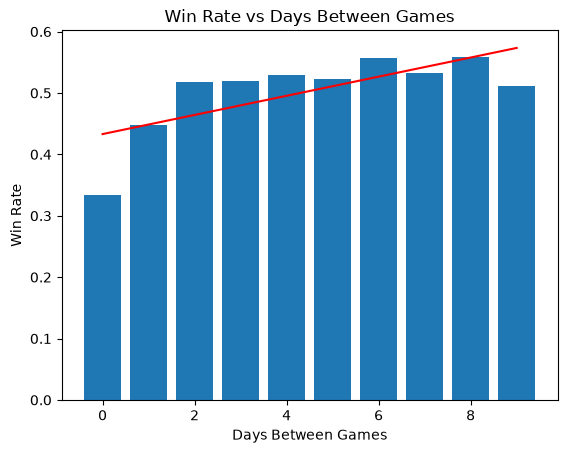

Slope: 0.015589364960987442


In [3]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

fig, ax = plt.subplots()
days = list(key for key in time_to_win.keys() if key < 10)
win_rate = [time_to_win[day].wins / time_to_win[day].count if time_to_win[day].count > 0 else 0 for day in days]

x_line = np.linspace(min(days), max(days), 100)
result = linregress(days, win_rate)

y_line = result.slope * x_line + result.intercept

ax.plot(
    x_line,
    y_line,
    label=f"y = {result.slope:.2f}x + {result.intercept:.2f}",
    color="red"
)

ax.bar(days, win_rate)
ax.set_xlabel("Days Between Games")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate vs Days Between Games")
plt.show()

#print(f"Slope: {result.slope}, Intercept: {result.intercept}, R-value: {result.rvalue}, P-value: {result.pvalue}, Std Err: {result.stderr}")
print(f"Slope: {result.slope}")

# Nejlepší hráč v týmu

In [4]:
games_combined = games.merge(pandas.read_csv(".data/NBA Dataset: Box Scores and Stats (1947 - Today)/Games.csv", low_memory=False), left_on="game_id", right_on="gameId", how="inner")

player_stats = pandas.read_csv(".data/NBA Dataset: Box Scores and Stats (1947 - Today)/PlayerStatisticsExtended.csv", low_memory=False)

notes: přes každý zapas, udělat to spojitě jedna osa procentuálně kolik udělal nejelpší hráč z všech a potom zda vyhráli nebo ne

In [9]:
unique_pairs = player_stats[['gameId','playerteamId']].drop_duplicates().reset_index(drop=True)
print(unique_pairs)

data_points = []

for _, row in unique_pairs.iterrows():
    game_id = row['gameId']
    team_id = row['playerteamId']
    
    # Filter player stats for the specific game and team
    team_player_stats = player_stats[(player_stats['gameId'] == game_id) & (player_stats['playerteamId'] == team_id)]

    max_points = team_player_stats['points'].max()
    sum_points = team_player_stats['points'].sum()
    won = team_player_stats['win'].iloc[0] == 1 if not team_player_stats.empty else None

    data_points.append((max_points, sum_points, won))
    
    # Perform analysis on team_player_stats as needed
    #print(f"Game ID: {game_id}, Team ID: {team_id}, Player Stats Count: {len(team_player_stats)}, Max Points: {max_points}, Sum Points: {sum_points}, Won: {won}")

         gameId  playerteamId
0      42500405  1.610613e+09
1      42500405  1.610613e+09
2      42500404  1.610613e+09
3      42500404  1.610613e+09
4      42500403  1.610613e+09
...         ...           ...
76154  12300067           NaN
76155  12400002           NaN
76156  12400011           NaN
76157  12400029           NaN
76158  12400060           NaN

[76159 rows x 2 columns]


76159 2162


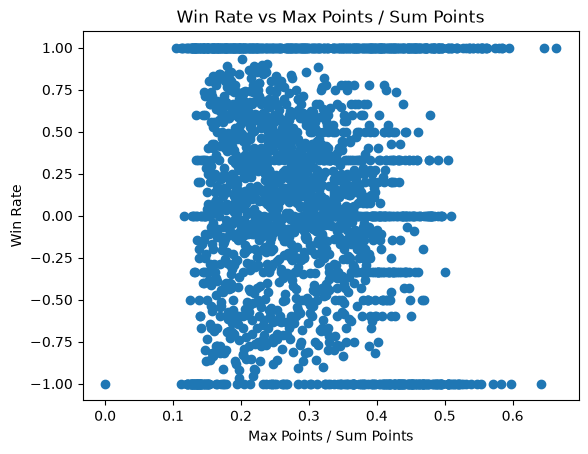

In [19]:
x_axis = [m / s if s != 0 else 0 for m, s, _ in data_points]
y_axis = [1 if won else -1 for _, _, won in data_points]

# Group by x-axis and calculate average y-value
from collections import defaultdict
grouped = defaultdict(list)
for x, y in zip(x_axis, y_axis):
    grouped[x].append(y)

x_aggregated = list(grouped.keys())
y_aggregated = [sum(values) / len(values) for values in grouped.values()]

print(len(x_axis), len(x_aggregated))

fig, ax = plt.subplots()
ax.scatter(x_aggregated, y_aggregated)
ax.set_xlabel("Max Points / Sum Points")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate vs Max Points / Sum Points")
plt.show()

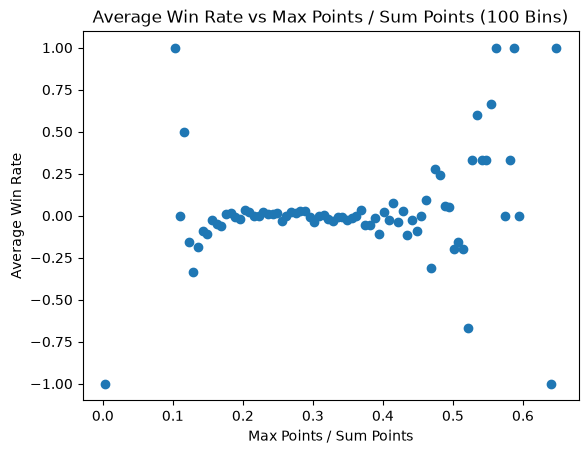

Original points: 76159, Binned points: 77


In [ ]:
intervals = 100

x_min = min(x_axis)
x_max = max(x_axis)
bin_edges = np.linspace(x_min, x_max, intervals + 1)  # intervals + 1 edges for intervals bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

bins_dict = {i: [] for i in range(intervals)}
for x, y in zip(x_axis, y_axis):
    bin_idx = np.digitize(x, bin_edges) - 1
    if 0 <= bin_idx < intervals:
        bins_dict[bin_idx].append(y)

x_binned = []
y_binned = []
for i in range(intervals):
    if bins_dict[i]:  
        x_binned.append(bin_centers[i])
        y_binned.append(sum(bins_dict[i]) / len(bins_dict[i]))

fig, ax = plt.subplots()
ax.scatter(x_binned, y_binned)
ax.set_xlabel("Max Points / Sum Points")
ax.set_ylabel("Average Win Rate")
ax.set_title(f"Average Win Rate vs Max Points / Sum Points ({intervals} Bins)")
plt.show()

print(f"Original points: {len(x_axis)}, Binned points: {len(x_binned)}")


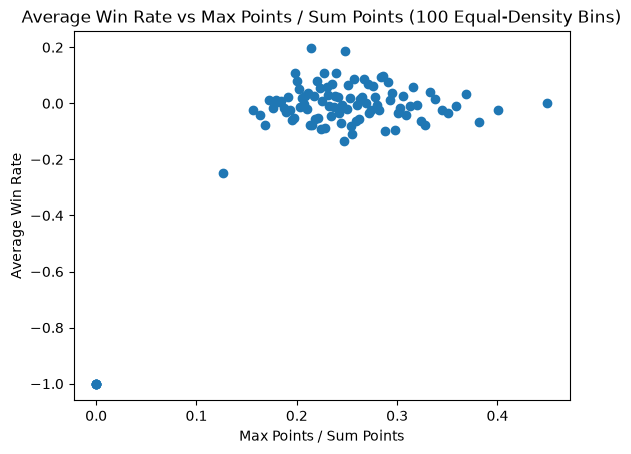

Original points: 76159, Binned points: 100


In [ ]:
#equal-density intervals
intervals = 100

sorted_indices = np.argsort(x_axis)
bin_size = len(x_axis) // intervals

x_binned = []
y_binned = []

for i in range(intervals):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < intervals - 1 else len(x_axis)
    
    if start_idx < len(x_axis):
        bin_indices = sorted_indices[start_idx:end_idx]
        bin_x = [x_axis[j] for j in bin_indices]
        bin_y = [y_axis[j] for j in bin_indices]
        
        if bin_x:  
            x_binned.append(np.mean(bin_x))
            y_binned.append(np.mean(bin_y))

fig, ax = plt.subplots()
ax.scatter(x_binned, y_binned)
ax.set_xlabel("Max Points / Sum Points")
ax.set_ylabel("Average Win Rate")
ax.set_title(f"Average Win Rate vs Max Points / Sum Points ({len(x_binned)} Equal-Density Bins)")
plt.show()

print(f"Original points: {len(x_axis)}, Binned points: {len(x_binned)}")
